In [1]:
import cv2
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
import pandas as pd
import os
import matplotlib.pyplot as plt

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from google.colab import drive


drive.mount('/content/drive')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

Mounted at /content/drive
cuda:0


In [2]:
ROOT_DIR = "drive/MyDrive/dataset/object_detection"
TRAIN_DIR = os.path.join(ROOT_DIR, 'training_images')
TEST_DIR = os.path.join(ROOT_DIR, 'testing_images')
BOXES_DIR = os.path.join(ROOT_DIR, 'train_solution_bounding_boxes.csv')
NUM_CLASSES = 2
EPOCHS = 10

In [90]:
class CarsDataset(torch.utils.data.Dataset):
    def __init__(self, dir, boxes_dir, transforms=None, is_test=False):
        self.transforms = transforms
        self.dir = dir
        self.boxes = pd.read_csv(BOXES_DIR)
        self.imgs = list(sorted(os.listdir(self.dir)))
        if not is_test:
            self.imgs = list(filter(lambda x: x in self.boxes['image'].unique(), self.imgs))

    def __getitem__(self, idx):
        img_path = os.path.join(self.dir, self.imgs[idx])
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)

        df = self.boxes[self.boxes['image'] == self.imgs[idx]]
        boxes, num_objs = [], len(df)
        for i, row in df.iterrows():
            boxes.append([row['xmin'], row['ymin'], row['xmax'], row['ymax']])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.ones((num_objs,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels

        if self.transforms is not None:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.imgs)

In [110]:
ds = CarsDataset(TRAIN_DIR, BOXES_DIR)

In [111]:
def plot_img(item):

    fig, ax = plt.subplots(1, 2, figsize = (14, 14))
    ax = ax.flatten()

    image = item[0]

    bboxes = item[1]['boxes']
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32)
    image /= 255.0
    image2 = image

    ax[0].set_title('Original Image')
    ax[0].imshow(image)

    for box in bboxes:
        x1 = box[0]
        y1 = box[1]
        x2 = box[2]
        y2 = box[3]

        cv2.rectangle(image2, (int(x1),int(y1)), (int(x2),int(y2)), (255,0,0), 3)

    ax[1].set_title('Image with Bondary Box')
    ax[1].imshow(image2)

    plt.show()


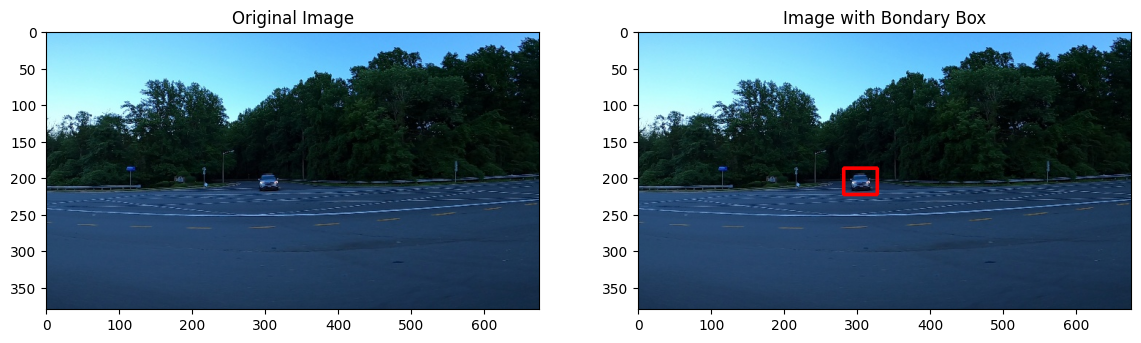

In [112]:
plot_img(ds[0])

In [126]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [114]:
def get_transform():
    return T.Compose([T.ToTensor()])

def collate_fn(batch):
    return tuple(zip(*batch))

In [115]:
train_dataset = CarsDataset(TRAIN_DIR, BOXES_DIR, transforms = get_transform())
test_dataset = CarsDataset(TEST_DIR, BOXES_DIR, transforms = get_transform(), is_test=True)
len(train_dataset), len(test_dataset)

(355, 175)

In [116]:
train_data_loader = DataLoader(
    train_dataset,
    batch_size = 1,
    shuffle = True,
    num_workers = 4,
    collate_fn = collate_fn
)


test_data_loader = DataLoader(
    test_dataset,
    batch_size = 1,
    shuffle = True,
    num_workers = 4,
    collate_fn = collate_fn
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [127]:
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [128]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

In [130]:
LOSSES = []

In [131]:
def train(model, optimizer, data_loader, device, epoch):
    mean_loss = 0

    print('-' * 10)
    print(f'Epoch {epoch}')

    for images, targets in data_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        out = model(images, targets)

        losses = sum(loss for loss in out.values())

        losses.backward()
        optimizer.step()

        mean_loss += losses

    mean_loss /= len(data_loader)
    LOSSES.append(mean_loss)
    print(mean_loss)

In [132]:
model.train()
for epoch in range(EPOCHS):
    train(model, optimizer, train_data_loader, device, f"{epoch + 1}/{EPOCHS}")

----------
Epoch 1/10
tensor(0.1463, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 2/10
tensor(0.1056, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 3/10
tensor(0.0905, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 4/10
tensor(0.0789, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 5/10
tensor(0.0695, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 6/10
tensor(0.0621, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 7/10
tensor(0.0560, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 8/10
tensor(0.0495, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 9/10
tensor(0.0443, device='cuda:0', grad_fn=<DivBackward0>)
----------
Epoch 10/10
tensor(0.0439, device='cuda:0', grad_fn=<DivBackward0>)


In [133]:
torch.save(model, "fasterrcnn.pt")

In [134]:
def convert(tensor):
    return [t.detach().cpu().numpy() for t in tensor]

def plot_build(title, data):
    plt.figure(figsize=(12, 8))
    plt.plot(range(len(data)), data)
    plt.xlabel("Epoch")
    plt.ylabel(title)
    plt.show()

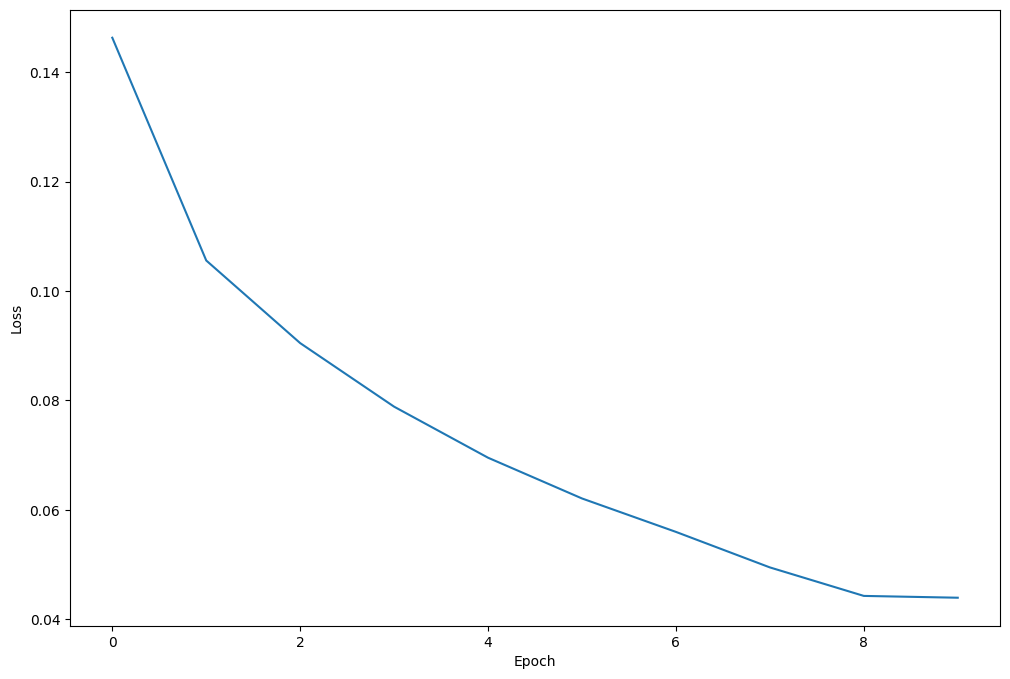

In [135]:
plot_build('Loss', convert(LOSSES))

In [106]:
model = torch.load("fasterrcnn.pt", weights_only=False)

In [151]:
model.eval()

image, target = test_dataset[12]
images = list(image.to(device) for image in [image])
targets = [{k: v.to(device) for k, v in t.items()} for t in [target]]
out = model(images)
out

[{'boxes': tensor([[603.0392, 177.9825, 675.3010, 232.0872]], device='cuda:0',
         grad_fn=<StackBackward0>),
  'labels': tensor([1], device='cuda:0'),
  'scores': tensor([0.9980], device='cuda:0', grad_fn=<IndexBackward0>)}]

In [152]:
def plot_img_out(source_image, out_model):

    img_new = source_image.mul(255).permute(1, 2, 0).byte().numpy()
    image = cv2.cvtColor(img_new, cv2.COLOR_BGR2RGB).astype(np.float32)
    image /= 255.0

    bboxes = out[0]['boxes']
    scores = out[0]['scores']

    for box, s in zip(bboxes, scores):
        if s > 0.75:
            x1, y1, x2, y2 = box.cpu().detach().numpy()
            cv2.rectangle(image, (int(x1),int(y1)), (int(x2),int(y2)), (255,0,0), 3)

    plt.imshow(image)

    plt.show()

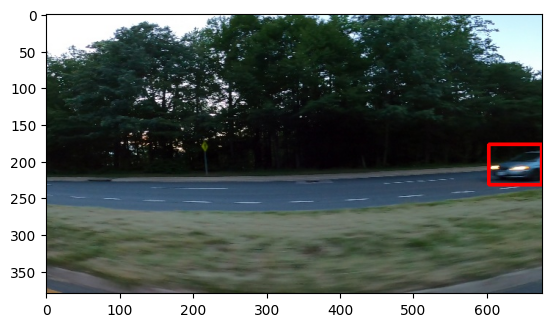

In [153]:
plot_img_out(image, out)